In [14]:
import pymc as pm
import numpy as np
import matplotlib.pyplot as plt
import random
import arviz as az

In [15]:
def getTosses(p: float, n: int) -> list:
    tosses = []
    for i in range(n):
        toss = 1 if random.random() < p else 0
        tosses.append(toss)
    return tosses

547


Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [p]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1 seconds.


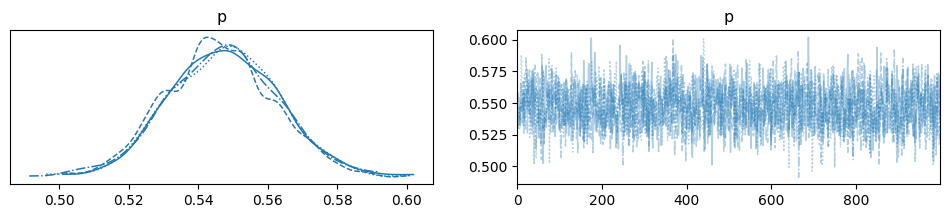

In [16]:
with pm.Model() as model:
    parameter = pm.Beta("p", alpha=1, beta=1)
    N = 1000
    data = getTosses(0.55, N)
    print(sum(data))
    heads = pm.Binomial("heads", p=parameter, n=N, observed=sum(data))
    trace = pm.sample()
    az.plot_trace(trace)


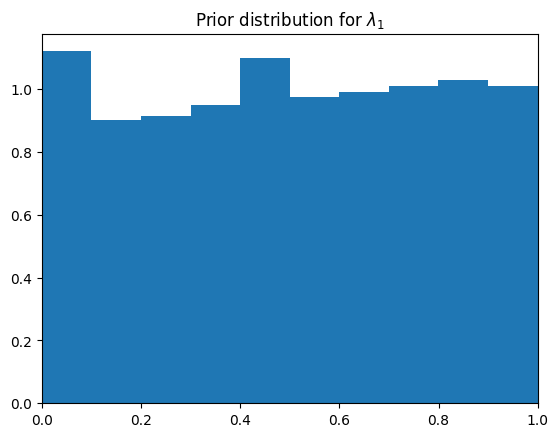

In [17]:
samples = [pm.draw(parameter) for i in range(2000)]
plt.hist(samples, bins=10, density=True)
plt.title("Prior distribution for $\lambda_1$")
plt.xlim(0, 1);

In [27]:
weights = [89.9, 89.8, 89.8, 90.2, 90.1, 90.4, 90.5, 90.9, 90.7, 90.8, 89.7, 90.9, 89.9, 90.4, 90.5, 90.7, 90.8, 90.9, 91, 91.1, 91.2, 91.2, 91.4, 91.5, 91.4, 91.5, 91.6, 91.3, 91.5, 90.9, 90.5, 89.8, 89.9, 90.4, 89.6, 89, 89, 89.5, 88.7, 88.8, 88.6, 88.1, 87.6, 87.9, 88, 87.5, 88.2, 87.5, 87.6, 87.3, 87.5, 87.8, 87, 87.1, 88.1, 87.2, 87.3, 87.4, 87.5, 87.2, 86.8, 87, 86.8, 86.4, 87.5, 86.7, 86.1, 86.3, 87.3, 87.2, 87.1, 87.9, 87.1]

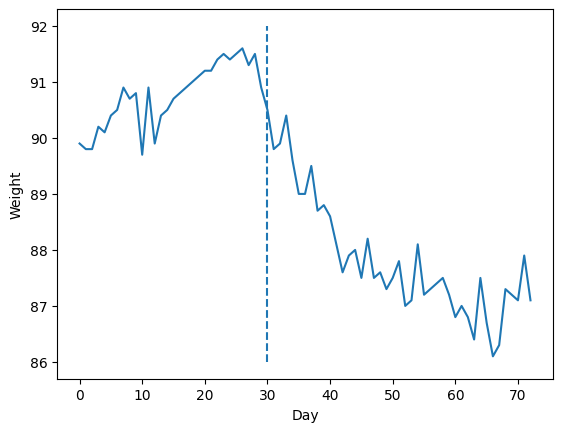

In [36]:
fig, ax = plt.subplots()
ax.set_xlabel("Day")
ax.set_ylabel("Weight")
ax.vlines(30, 86, 92, linestyles="dashed")
ax.plot(weights)
plt.savefig("weights.pdf")

In [29]:
np.mean(weights)

89.04520547945205

In [39]:
days = 73
t = np.arange(days)

with pm.Model() as model:
    # Change point prior: uniform over time
    tau = pm.DiscreteUniform("tau", lower=0, upper=73)

    # Priors for slopes and intercepts
    alpha1 = pm.Normal("alpha1", mu=89, sigma=5)
    beta1 = pm.Normal("beta1", mu=0, sigma=1)
    alpha2 = pm.Normal("alpha2", mu=89, sigma=5)
    beta2 = pm.Normal("beta2", mu=0, sigma=1)

    # Piecewise linear model
    mu = pm.math.switch(
        t < tau,
        alpha1 + beta1 * t,
        alpha2 + beta2 * t
    )

    # Observed weights
    y = pm.Normal("y", mu=mu, sigma=0.5, observed=weights)

    # Inference
    trace = pm.sample(2000, tune=2000, target_accept=0.9)

Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>Metropolis: [tau]
>NUTS: [alpha1, beta1, alpha2, beta2]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 5 seconds.


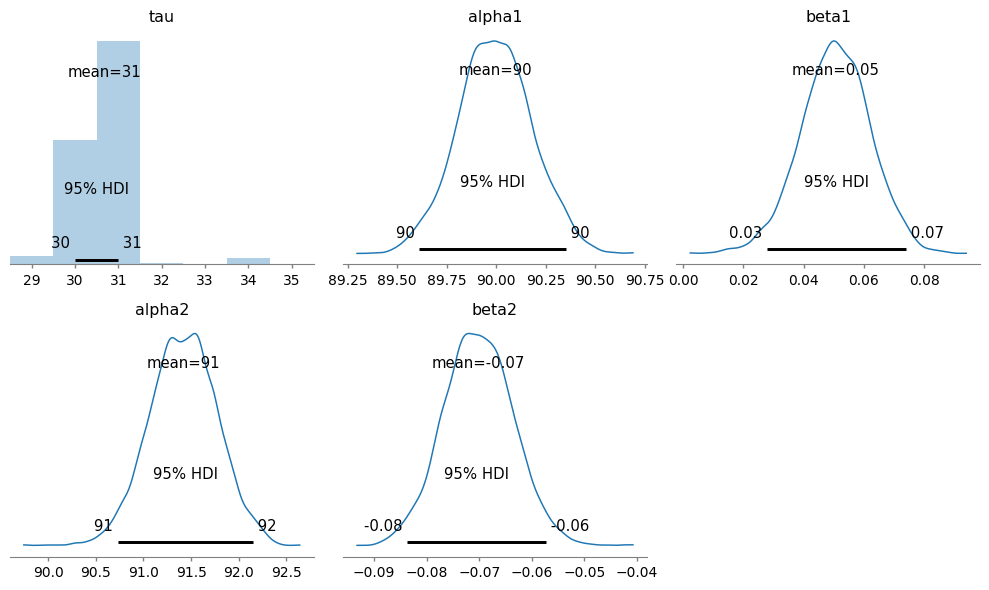

In [48]:
az.plot_posterior(
    trace,
    hdi_prob=0.95,             # Use 95% credible interval (standard in papers)
    kind="kde",                # Clean smooth line (or 'hist' if you prefer)
    point_estimate="mean",     # Or 'median'
    round_to=1,                # Round axis values
    figsize=(10, 6),            # Adjust size to fit better
    textsize=10,               # Control font size for axis/labels
    ref_val=None,              # Remove vertical reference line
    rope=None,                 # Remove Region of Practical Equivalence
)
plt.tight_layout()
plt.savefig("posteriorWeight.pdf")

/var/folders/c8/mqhljcz12rld881pkd18bzxc0000gn/T/ipykernel_7231/853342893.py:16: FutureWarning: hdi currently interprets 2d data as (draw, shape) but this will change in a future release to (chain, draw) for coherence with other functions
  mu_hdi = az.hdi(posterior_lines, hdi_prob=0.95)


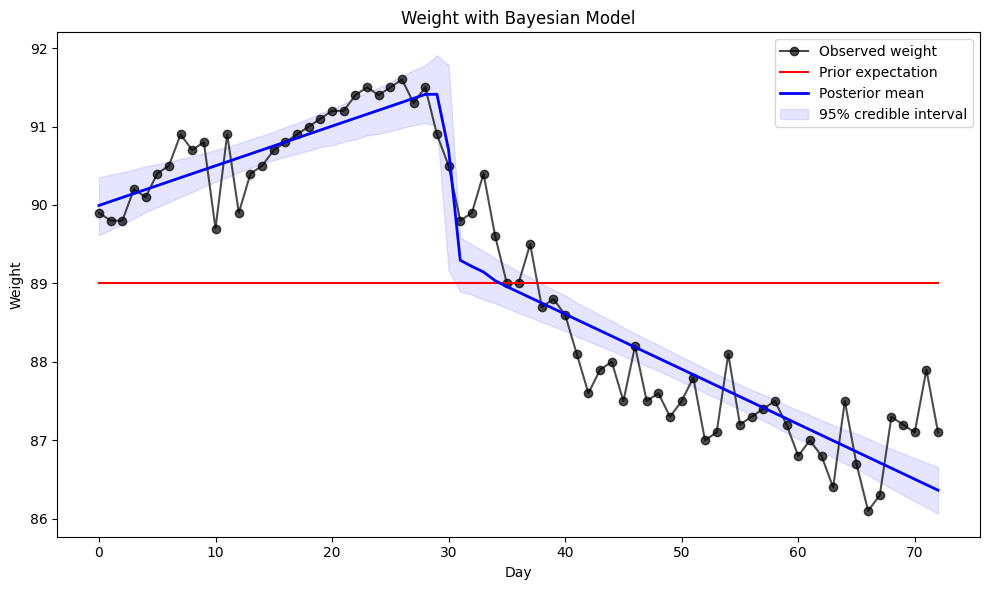

In [52]:
posterior = trace.posterior
alpha1_samples = posterior["alpha1"].values.flatten()
beta1_samples = posterior["beta1"].values.flatten()
alpha2_samples = posterior["alpha2"].values.flatten()
beta2_samples = posterior["beta2"].values.flatten()
tau_samples = posterior["tau"].values.flatten()

posterior_lines = []

for a1, b1, a2, b2, tau in zip(alpha1_samples, beta1_samples, alpha2_samples, beta2_samples, tau_samples):
    mu_t = np.where(t < tau, a1 + b1 * t, a2 + b2 * t)
    posterior_lines.append(mu_t)

posterior_lines = np.array(posterior_lines)
mu_mean = posterior_lines.mean(axis=0)
mu_hdi = az.hdi(posterior_lines, hdi_prob=0.95)

plt.figure(figsize=(10, 6))

# Plot observed data
plt.plot(t, weights, 'o-', label="Observed weight", color="black", alpha=0.7)

# Plot prior mean (just for illustration — not sampled from model)
alpha1_prior, beta1_prior = 89, 0
alpha2_prior, beta2_prior = 89, 0
prior_tau = 36
mu_prior = np.where(t < prior_tau, alpha1_prior + beta1_prior * t, alpha2_prior + beta2_prior * t)
plt.plot(t, mu_prior, label="Prior expectation", color="red")

# Plot posterior mean and credible band
plt.plot(t, mu_mean, label="Posterior mean", color="blue", linewidth=2)
plt.fill_between(t, mu_hdi[:, 0], mu_hdi[:, 1], color="blue", alpha=0.1, label="95% credible interval")

plt.xlabel("Day")
plt.ylabel("Weight")
plt.title("Weight with Bayesian Model")
plt.legend()
plt.tight_layout()
plt.savefig("bayesianWeight.pdf")
plt.show()

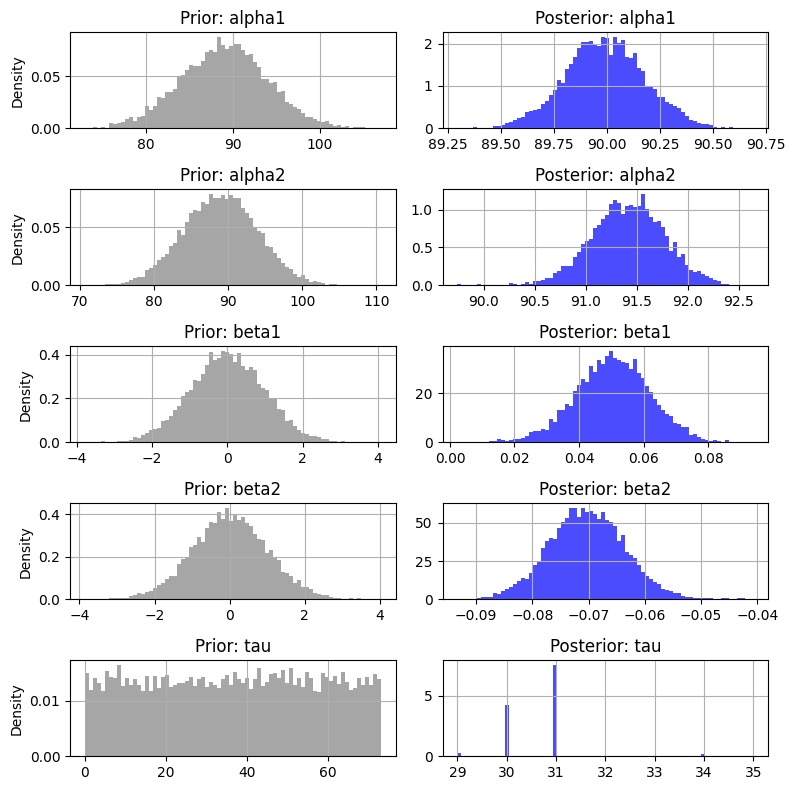

In [61]:
prior_samples = {
    "alpha1": np.random.normal(89, 5, 10000),
    "beta1": np.random.normal(0, 1, 10000),
    "alpha2": np.random.normal(89, 5, 10000),
    "beta2": np.random.normal(0, 1, 10000),
    "tau": np.random.randint(0, 74, 10000),  # 0 to 73 inclusive
}

# --- Extract posterior samples from trace
posterior = trace.posterior
posterior_samples = {
    "alpha1": posterior["alpha1"].values.flatten(),
    "beta1": posterior["beta1"].values.flatten(),
    "alpha2": posterior["alpha2"].values.flatten(),
    "beta2": posterior["beta2"].values.flatten(),
    "tau": posterior["tau"].values.flatten(),
}

# --- Plotting
params = ["alpha1", "alpha2", "beta1", "beta2", "tau"]
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(8, 8))

for i, param in enumerate(params):
    # Prior on left
    axes[i, 0].hist(prior_samples[param], bins=74, density=True, color="gray", alpha=0.7)
    axes[i, 0].set_title(f"Prior: {param}")
    axes[i, 0].set_ylabel("Density")

    # Posterior on right
    axes[i, 1].hist(posterior_samples[param], bins=74, density=True, color="blue", alpha=0.7)
    axes[i, 1].set_title(f"Posterior: {param}")

for ax in axes.flat:
    ax.grid(True)

plt.tight_layout()
plt.savefig("distComparison.pdf")
plt.show()
